# KcELECTRA 파인튜닝 v2 — 2026-05-04

**담당:** 경이 (kyeongyi)  
**목적:** 자동 라벨링으로 확장한 v4 데이터(695개)로 KcELECTRA를 재학습하여  
베이스라인(Simple Macro F1 = 0.7919)을 넘기는 것이 목표.

---

## v1 대비 핵심 개선 사항 (왜 v1이 실패했나?)

| 문제 | v1 설정 | v2 개선 |
|------|---------|--------|
| 데이터 부족 | 196개 (train) | **556개** (3배 증가) |
| 클래스 불균형 무시 | CrossEntropyLoss (일반) | **WeightedCrossEntropyLoss** |
| 에폭 부족 | 5 에폭 | **15 에폭** |
| 학습률 너무 큼 | 3e-5 | **2e-5** (더 안정적) |
| 워밍업 짧음 | 10% | **20%** |

---

## 실행 전 체크리스트

- [ ] 런타임 → **GPU** 선택 (T4 이상)
- [ ] `split_v2_20260504.csv` 업로드
- [ ] `notice_sample_v4_20260504.csv` 업로드 (참고용)

## 완료 후 해야 할 일

1. `checkpoints/kcelectra-category-v2/` 폴더 다운로드
2. 로컬 `model/classification/checkpoints/kcelectra-category-v2/` 에 붙여넣기
3. `eval_results_kcelectra_20260504.json` 다운로드 → `model/classification/data/` 에 복사
4. `python scripts/evaluate_compare_v2_20260504.py` 재실행 → 비교 결과 확인

In [1]:
# ── 셀 1: 라이브러리 설치 (Colab에서만 실행) ──────────────────────
# Colab: 아래 주석 해제 후 실행
!pip install transformers datasets seaborn matplotlib scikit-learn -q

# 로컬 venv: 아래 명령으로 설치
# pip install torch transformers datasets seaborn matplotlib scikit-learn

In [2]:
# ── 셀 2: 시드 고정 + GPU 확인 ────────────────────────────────────
# 왜 시드를 고정하나?
#   동일한 데이터·코드로 실행해도 난수 초기화가 다르면 결과가 달라짐.
#   seed=42로 고정 → 누가 실행해도 동일한 결과 재현 가능.

import os, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[경고] GPU 없음 — CPU로 실행하면 수 시간 걸릴 수 있음")

Device: cuda
GPU: Tesla T4


In [3]:
# ── 셀 3: 하이퍼파라미터 설정 ─────────────────────────────────────
# 모든 설정을 한 곳에 모아 추후 튜닝이 쉽도록 설계.

from pathlib import Path

# Colab vs 로컬 환경 자동 감지
_IN_COLAB = os.path.exists("/content")

if _IN_COLAB:
    DATA_DIR  = Path("/content")
    CKPT_DIR  = Path("/content/kcelectra-category-v2")
    EVAL_JSON = Path("/content/eval_results_kcelectra_20260504.json")
else:
    _BASE     = Path(".").resolve()  # notebooks/ 위치
    DATA_DIR  = _BASE.parent / "data"
    CKPT_DIR  = _BASE.parent / "checkpoints" / "kcelectra-category-v2"
    EVAL_JSON = DATA_DIR / "eval_results_kcelectra_20260504.json"

SPLIT_CSV = DATA_DIR / "split_v2_20260504.csv"

# 학습 설정
BASE_MODEL   = "monologg/koelectra-small-v3-discriminator"  # KcELECTRA 사전학습 모델
MAX_LEN      = 128    # 토크나이저 최대 토큰 수 (학교 공지 문장은 대부분 128 이하)
BATCH_SIZE   = 16     # OOM 발생 시 8로 줄이기
EPOCHS       = 15     # v1(5 에폭) → v2(15 에폭): 소량 데이터 파인튜닝 권장 범위
LR           = 2e-5   # v1(3e-5)보다 낮춤: 사전학습 가중치 보존하며 안정적 학습
WARMUP_RATIO = 0.2    # v1(0.1) → v2(0.2): 초반 20% 스텝은 학습률 서서히 증가

LABELS = ["일정", "준비물", "제출", "비용", "건강·안전", "기타"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

print(f"데이터: {SPLIT_CSV}")
print(f"체크포인트 저장: {CKPT_DIR}")
print(f"설정: {EPOCHS}에폭, LR={LR}, BS={BATCH_SIZE}, MaxLen={MAX_LEN}")

데이터: /content/split_v2_20260504.csv
체크포인트 저장: /content/kcelectra-category-v2
설정: 15에폭, LR=2e-05, BS=16, MaxLen=128


In [4]:
# ── 셀 4: 데이터 로드 ─────────────────────────────────────────────
import pandas as pd
from collections import Counter

df = pd.read_csv(SPLIT_CSV, encoding="utf-8-sig")
df = df[df["category"].isin(LABELS)].dropna(subset=["text", "category"])

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)}개")
print(f"Val:   {len(val_df)}개")
print(f"Test:  {len(test_df)}개")

print("\nTrain 카테고리 분포:")
for lbl, cnt in Counter(train_df["category"]).items():
    print(f"  {lbl}: {cnt}개")

Train: 556개
Val:   70개
Test:  69개

Train 카테고리 분포:
  비용: 78개
  일정: 105개
  기타: 110개
  건강·안전: 90개
  제출: 109개
  준비물: 64개


In [5]:
# ── 셀 5: Dataset + DataLoader 생성 ──────────────────────────────
# PyTorch Dataset 클래스: 모델이 읽을 수 있는 형식으로 변환.
# KcELECTRA는 입력을 token_ids + attention_mask 형태로 받음.

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)


class NoticeDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.texts  = df["category"].tolist()   # 사용 안 함 (아래서 수정)
        self.texts  = df["text"].tolist()
        self.labels = [LABEL2ID[c] for c in df["category"]]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_loader = DataLoader(NoticeDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NoticeDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NoticeDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoader 생성 완료")
print(f"  train batches: {len(train_loader)}")
print(f"  val   batches: {len(val_loader)}")
print(f"  test  batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

DataLoader 생성 완료
  train batches: 35
  val   batches: 5
  test  batches: 5


In [6]:
# ── 셀 6: 가중치 손실 함수 계산 ──────────────────────────────────
#
# v1 실패 원인 #2: 클래스 불균형 처리 안 함.
# v2 개선: WeightedCrossEntropyLoss 적용
#
# 계산 공식: weight[i] = total / (num_classes * count[i])
#   - 적은 클래스(준비물 80개) → 높은 가중치 → 틀렸을 때 패널티 크다
#   - 많은 클래스(기타 138개) → 낮은 가중치 → 틀려도 패널티 작다
# 이렇게 하면 모델이 특정 클래스로 편향되지 않음.

label_counts = [int((train_df["category"] == lbl).sum()) for lbl in LABELS]
total = sum(label_counts)
class_weights = torch.tensor(
    [total / (len(LABELS) * c) for c in label_counts],
    dtype=torch.float
).to(DEVICE)

print("클래스 가중치:")
for lbl, cnt, w in zip(LABELS, label_counts, class_weights):
    print(f"  {lbl:8s}: {cnt:3d}개  가중치={w:.3f}")

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

클래스 가중치:
  일정      : 105개  가중치=0.883
  준비물     :  64개  가중치=1.448
  제출      : 109개  가중치=0.850
  비용      :  78개  가중치=1.188
  건강·안전   :  90개  가중치=1.030
  기타      : 110개  가중치=0.842


In [7]:
# ── 셀 7: 모델 초기화 ─────────────────────────────────────────────
# AutoModelForSequenceClassification:
#   KcELECTRA 인코더 위에 분류 헤드(Linear layer)를 붙인 구조.
#   num_labels=6 → 6개 카테고리 분류.

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델 파라미터: 전체={total_params:,} / 학습가능={trainable:,}")

pytorch_model.bin:   0%|          | 0.00/56.6M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-small-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missi

모델 파라미터: 전체=14,123,526 / 학습가능=14,123,526


In [8]:
# ── 셀 8: Optimizer + Scheduler ──────────────────────────────────
# AdamW: Adam + Weight Decay → 파인튜닝 표준 옵티마이저.
# LinearWarmup:
#   처음 20% 스텝은 LR 0 → LR_MAX로 서서히 올림.
#   이유: 파인튜닝 초반에 LR이 갑자기 크면 사전학습 가중치가 망가짐.
#   이후 선형 감소: LR_MAX → 0.

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=LR)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"전체 스텝: {total_steps}, 워밍업 스텝: {warmup_steps} ({WARMUP_RATIO*100:.0f}%)")

전체 스텝: 525, 워밍업 스텝: 105 (20%)


In [9]:
# ── 셀 9: 학습 루프 ───────────────────────────────────────────────
# Best 모델 저장 전략:
#   매 에폭마다 Val Macro F1을 계산하고, 이전보다 높으면 체크포인트 저장.
#   최종 저장된 모델이 'best' 모델.
#
# 핵심: loss_fn(outputs.logits, labels) — 가중치 손실 사용!
#       outputs.loss 대신 우리가 정의한 loss_fn을 씀.

from sklearn.metrics import f1_score

def evaluate_epoch(loader, split_name="val"):
    """한 에폭 평가: Macro F1 반환."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn_mask = batch["attention_mask"].to(DEVICE)
            labels    = batch["label"].to(DEVICE)
            logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits
            preds     = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return f1_score(all_labels, all_preds, average="macro", zero_division=0)


train_losses, val_f1s = [], []
best_val_f1 = 0.0

CKPT_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = loss_fn(outputs.logits, labels)   # 가중치 손실!

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient Clipping
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val_f1   = evaluate_epoch(val_loader, "val")
    train_losses.append(avg_loss)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}", end="")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(CKPT_DIR)
        tokenizer.save_pretrained(CKPT_DIR)
        print(f"  [저장] Best 갱신!")
    else:
        print()

print(f"\n학습 완료. Best Val F1: {best_val_f1:.4f}")

Epoch  1/15 | Loss: 1.7915 | Val F1: 0.1575

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신!
Epoch  2/15 | Loss: 1.7893 | Val F1: 0.2586

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신!
Epoch  3/15 | Loss: 1.7833 | Val F1: 0.3485

...

  [저장] Best 갱신!
Epoch  8/15 | Loss: 1.5042 | Val F1: 0.6735

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신!
Epoch  9/15 | Loss: 1.4530 | Val F1: 0.6664
Epoch 10/15 | Loss: 1.4095 | Val F1: 0.7486

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신!
Epoch 11/15 | Loss: 1.3753 | Val F1: 0.7291
Epoch 12/15 | Loss: 1.3461 | Val F1: 0.7447
Epoch 13/15 | Loss: 1.3245 | Val F1: 0.7290
Epoch 14/15 | Loss: 1.3078 | Val F1: 0.7439
Epoch 15/15 | Loss: 1.3004 | Val F1: 0.7443

학습 완료. Best Val F1: 0.7486


In [10]:
# ── 셀 10: label2id.json 저장 ─────────────────────────────────────
# classifier_kcelectra.py에서 라벨 매핑을 읽는 파일.
# v1에서 이 파일이 없어서 '전 카테고리 F1=0' 문제가 발생했었음.

import json

label2id_path = CKPT_DIR / "label2id.json"
with open(label2id_path, "w", encoding="utf-8") as f:
    json.dump(LABEL2ID, f, ensure_ascii=False, indent=2)
print(f"label2id.json 저장: {label2id_path}")
print(LABEL2ID)

label2id.json 저장: /content/kcelectra-category-v2/label2id.json
{'일정': 0, '준비물': 1, '제출': 2, '비용': 3, '건강·안전': 4, '기타': 5}


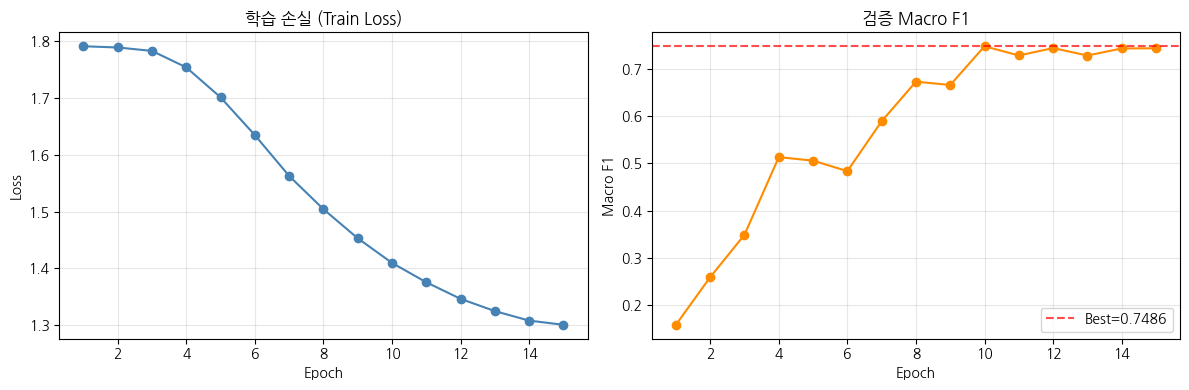

학습 곡선 저장 완료


In [11]:
# ── 셀 11: 학습 곡선 시각화 ───────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib
import platform

# OS별 한글 폰트 설정
if platform.system() == "Windows":
    matplotlib.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    matplotlib.rc("font", family="AppleGothic")
else:  # Linux (Colab)
    try:
        import subprocess
        subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
        import matplotlib.font_manager as fm
        fm.fontManager.__init__()
        matplotlib.rc("font", family="NanumGothic")
    except Exception:
        pass

matplotlib.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS+1), train_losses, marker="o", color="steelblue")
axes[0].set_title("학습 손실 (Train Loss)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), val_f1s, marker="o", color="darkorange")
axes[1].axhline(y=best_val_f1, color="red", linestyle="--", alpha=0.7, label=f"Best={best_val_f1:.4f}")
axes[1].set_title("검증 Macro F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "train_curve_kcelectra_v2_20260504.png", dpi=150, bbox_inches="tight")
plt.show()
print("학습 곡선 저장 완료")

In [12]:
# ── 셀 12: Test 세트 최종 평가 ────────────────────────────────────
# Best 체크포인트를 다시 로드해서 test 세트로 최종 평가.
# Val로 Best 선택 → Test로 최종 확인: 과적합(overfitting) 방지 표준 절차.

from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Best 체크포인트 로드
best_model = AutoModelForSequenceClassification.from_pretrained(
    CKPT_DIR, num_labels=len(LABELS)
).to(DEVICE)
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)
        logits    = best_model(input_ids=input_ids, attention_mask=attn_mask).logits
        preds     = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

pred_names  = [ID2LABEL[p] for p in all_preds]
true_names  = [ID2LABEL[l] for l in all_labels]
macro_f1    = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print("[KcELECTRA v2] Test 세트 최종 평가")
print(classification_report(true_names, pred_names, labels=LABELS, zero_division=0))
print(f"Macro F1: {macro_f1:.4f}")
print(f"베이스라인 대비: {macro_f1 - 0.7919:+.4f}")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[KcELECTRA v2] Test 세트 최종 평가
              precision    recall  f1-score   support

          일정       0.73      0.85      0.79        13
         준비물       0.50      0.88      0.64         8
          제출       0.77      0.77      0.77        13
          비용       0.90      0.90      0.90        10
       건강·안전       0.67      0.18      0.29        11
          기타       0.79      0.79      0.79        14

    accuracy                           0.72        69
   macro avg       0.73      0.73      0.69        69
weighted avg       0.74      0.72      0.70        69

Macro F1: 0.6938
베이스라인 대비: -0.0981


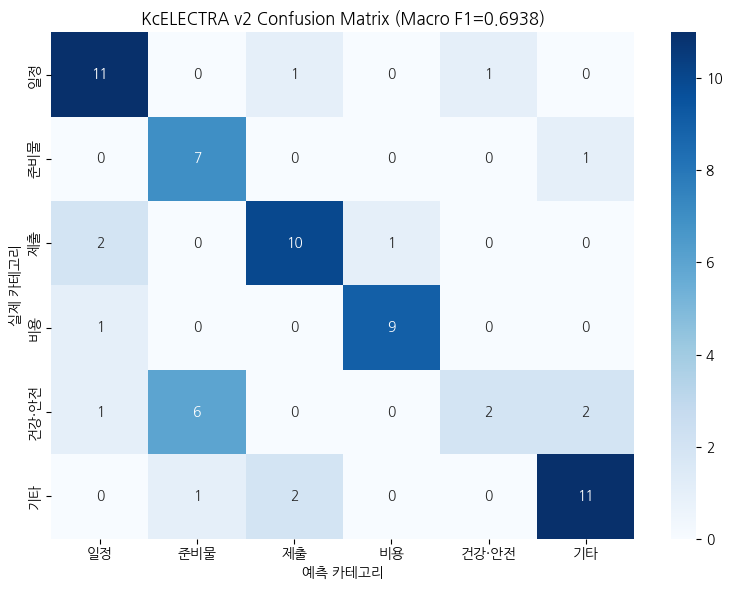

In [13]:
# ── 셀 13: Confusion Matrix ────────────────────────────────────────
import seaborn as sns

cm = confusion_matrix(true_names, pred_names, labels=LABELS)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("예측 카테고리")
ax.set_ylabel("실제 카테고리")
ax.set_title(f"KcELECTRA v2 Confusion Matrix (Macro F1={macro_f1:.4f})")
plt.tight_layout()
plt.savefig(DATA_DIR / "confusion_matrix_kcelectra_v2_20260504.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# ── 셀 14: 평가 결과 JSON 저장 ────────────────────────────────────
# evaluate_compare_v2_20260504.py가 이 JSON을 읽어 비교 분석.
# 로컬에 복사해야 할 파일!

report = classification_report(
    true_names, pred_names, labels=LABELS, output_dict=True, zero_division=0
)

result = {
    "model": "kcelectra",
    "macro_f1":        round(macro_f1, 4),
    "macro_precision": round(report["macro avg"]["precision"], 4),
    "macro_recall":    round(report["macro avg"]["recall"], 4),
    "per_class": {
        lbl: {
            "precision": round(report[lbl]["precision"], 4),
            "recall":    round(report[lbl]["recall"], 4),
            "f1":        round(report[lbl]["f1-score"], 4),
            "support":   report[lbl]["support"],
        }
        for lbl in LABELS
    },
    "confusion_matrix": cm.tolist(),
    "labels":           LABELS,
    "data_version":     "v4_20260504",
    "epochs":           EPOCHS,
    "lr":               LR,
    "batch_size":       BATCH_SIZE,
    "warmup_ratio":     WARMUP_RATIO,
    "weighted_loss":    True,
}

with open(EVAL_JSON, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f"[저장] {EVAL_JSON}")
print(f"\n★ 이 파일을 로컬 model/classification/data/ 에 복사하세요!")
print(f"★ kcelectra-category-v2/ 폴더도 checkpoints/ 에 복사하세요!")

[저장] /content/eval_results_kcelectra_20260504.json

★ 이 파일을 로컬 model/classification/data/ 에 복사하세요!
★ kcelectra-category-v2/ 폴더도 checkpoints/ 에 복사하세요!


In [15]:
import shutil
shutil.make_archive("/content/kcelectra-category-v2", "zip", "/content/kcelectra-category-v2")
print("압축 완료!")


압축 완료!


## 학습 완료 후 로컬 작업

```bash
# 1. JSON 복사 후 비교 실행
cd model/classification
python scripts/evaluate_compare_v2_20260504.py

# 2. 시각화 노트북 실행
jupyter notebook notebooks/04_visualize_comparison_20260504.ipynb
```